In [16]:
import importlib.util
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

import matrix_envs  # registers the env ids; also lets us read each game's true optimum

PROJECT = Path.cwd()


_spec = importlib.util.spec_from_file_location("run_sweep", PROJECT / "scripts" / "run_sweep.py")
sweep = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sweep)

> The matrix-game and MPE `simple_spread` sections have moved to **`games_sweep_archive.ipynb`**, which is a frozen record — the sacred runs behind them were deleted, so those figures cannot be regenerated and their cells no longer execute. Everything below runs against results still on disk.

## LBF `Foraging-5x5-2p-1f-coop-pen-rel_obs` — PAC

Two agents, one food, 5×5 grid. `-coop` sets the food's level to the sum of the player levels, so a load only pays off if **both** agents stand next to the food and pick `LOAD` on the same step; `-pen` gives a negative reward to every agent whose load attempt fails; its size is **not** recorded in the run output and is not the same for every run below, so it is reconstructed per run in the loader cell (these six: 0.6). `-rel_obs` is the new `RelativeObservationWrapper` (`lb-foraging/lbforaging/rel_obs_foraging.py`): every position in the observation is rewritten as a signed offset from the observing agent, so an agent reads "the food is 2 rows up and 1 column right" rather than a pair of absolute grid coordinates, and its own (always-zero) coordinates drop out — 7 values per agent instead of 9.

`pac_ns` only, 6 seeds, 25-step episodes, 14M environment steps, `reward_scalarisation="sum"` so the team return is +1 for the episode that collects the food and −`penalty` per failed solo load, and `test_greedy=False`, so the curves are the sampled policy rather than its argmax. These are the settings currently in `scripts/run_sweep.py`.

**All six seeds converge to 0, not to 1.** Each climbs out of the uniform-random regime and flattens onto zero by ~10M steps. Zero is not a partial solve — it is exactly the payoff of never attempting a load, and the table below confirms it: test episodes still run the full 25 steps in every seed, so the food is never collected. PAC finds the penalty-avoiding equilibrium and never crosses to the cooperative one.

The right-hand panel shows the policy is not collapsing to a deterministic no-op. Mean max action probability settles at ≈0.175, barely above the 1/6 ≈ 0.167 floor of a uniform distribution, held there by the entropy bonus (`final_entropy_coef: 0.02`). But a policy uniform over all six actions would score the random reference (−0.76), because a random agent standing next to the food picks `LOAD` about one step in six. Scoring 0 while staying that close to uniform means nearly all the probability mass PAC moved went into suppressing `LOAD`: the agents keep wandering, they have just learned not to reach.

In [17]:
LBF_ENV = "lbforaging:Foraging-5x5-2p-1f-coop-pen-rel_obs-v3"
LBF_ABS_ENV = "lbforaging:Foraging-5x5-2p-1f-coop-pen-v3"  # same task, stock absolute obs
LBF_ALG = "pac_ns"

# force_coop sets the food's level to the sum of the player levels, so only a
# simultaneous two-agent load succeeds. With `reward_scalarisation="sum"` the
# team return is +1 for the episode that collects the food, and -penalty for
# every solo load attempt that fails.
LBF_OPTIMUM = 1.0

# The budget these runs were trained on; comparable_runs() drops anything else.
LBF_TIME_LIMIT, LBF_T_MAX = 25, 14_000_000

# Reference return of a uniform-random policy, one per candidate `penalty`.
#
# The penalty a run was trained with is NOT recorded anywhere in the sacred
# output -- env_args carries only `key` and `time_limit` -- and the registration
# in lb-foraging/lbforaging/__init__.py was changed from 0.6 to 0.1 partway
# through this project, so the runs below do NOT all share it. These references
# are what lets infer_penalty() recover it: a run's opening evaluation points sit
# at the random-policy return, and the candidates are far enough apart to
# separate without ambiguity.
LBF_PENALTY_CANDIDATES = (0.1, 0.3, 0.6)

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # the id table re-registers a few ids
    import lbforaging  # registers the Foraging ids


def random_policy_return(penalty, n_episodes=500, seed=0):
    """Mean team return of a uniform-random policy at one `penalty` setting.

    `penalty` is passed to gym.make explicitly rather than read off the id, which
    now registers 0.1 and would misdescribe every run trained before that change.
    """
    # disable_env_checker: LBF returns one reward per agent, which the passive
    # checker flags as a non-float reward on every make().
    env = gym.make(LBF_ENV, max_episode_steps=25, penalty=penalty,
                   disable_env_checker=True)
    rng = np.random.default_rng(seed)
    n_actions = env.action_space[0].n
    returns = []
    for ep in range(n_episodes):
        env.reset(seed=ep)
        total = 0.0
        while True:
            actions = tuple(int(a) for a in rng.integers(n_actions, size=len(env.action_space)))
            _, rewards, terminated, truncated, _ = env.step(actions)
            total += float(np.sum(rewards))  # matches reward_scalarisation="sum"
            if terminated or truncated:
                break
        returns.append(total)
    return float(np.mean(returns))


LBF_RANDOM = {p: random_policy_return(p) for p in LBF_PENALTY_CANDIDATES}
for penalty, value in LBF_RANDOM.items():
    print(f"penalty {penalty}: uniform-random team return {value:+.2f}")

penalty 0.1: uniform-random team return -0.11
penalty 0.3: uniform-random team return -0.37
penalty 0.6: uniform-random team return -0.76


In [18]:
def infer_penalty(test_return, n_points=5):
    """Recover the `penalty` a run was trained with from its opening evaluation
    points. Inferred, never recorded -- see the cell above for why.

    The statistic is the *minimum* over the opening window, not its mean: the
    agents start at the random-policy return and learning only lifts them off
    it, so by the fifth evaluation point the mean is already biased upward --
    enough to misread two of the 0.6 runs as 0.3. The minimum tracks the floor.
    On the runs here it agrees with using the first point alone, and the
    candidate floors are ~6x apart, so the margins are wide."""
    floor = float(np.min(test_return[:n_points]))
    return min(LBF_RANDOM, key=lambda p: abs(LBF_RANDOM[p] - floor))


def load_sacred_runs(env_id, alg=LBF_ALG):
    """Every COMPLETED run for one env id, read straight from the sacred tree.

    Deliberately not sweep.completed_runs(): that only returns runs whose config
    still matches the sweep grid as it is *currently* written, so finished runs
    drop out of this notebook the moment scripts/run_sweep.py is retargeted at
    the next experiment. The settings that vary from run to run are kept as
    columns instead, so comparable_runs() can say what it discards and why.
    """
    env_dir = sweep.SACRED / sweep.sacred_name(alg) / env_id
    rows = []
    for run_dir in sorted(env_dir.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else -1):
        if not run_dir.name.isdigit():
            continue
        run_info = json.loads((run_dir / "run.json").read_text())
        if run_info["status"] != "COMPLETED":
            continue
        config = json.loads((run_dir / "config.json").read_text())
        metrics = json.loads((run_dir / "metrics.json").read_text())
        ret, ep_len, pi_max = (metrics["test_return_mean"],
                               metrics["test_ep_length_mean"], metrics["pi_max"])
        best = int(np.argmax(ret["values"]))
        start = datetime.fromisoformat(run_info["start_time"])
        stop = datetime.fromisoformat(run_info["stop_time"])
        rows.append({
            "env": env_id, "run": int(run_dir.name), "seed": config["seed"],
            "name": config["name"],  # sacred experiment name; see ALG_OVERRIDES
            "time_limit": config["env_args"]["time_limit"], "t_max": config["t_max"],
            "penalty": infer_penalty(ret["values"]),
            "steps": ret["steps"], "test_return": ret["values"],
            "ep_length": ep_len["values"],
            "pi_max_steps": pi_max["steps"], "pi_max": pi_max["values"],
            "final_return": ret["values"][-1],
            "best_return": ret["values"][best], "best_return_step": ret["steps"][best],
            "final_ep_length": ep_len["values"][-1], "min_ep_length": min(ep_len["values"]),
            "duration_s": (stop - start).total_seconds(),
        })
    return pd.DataFrame(rows)


def comparable_runs(env_id, name=None):
    """load_sacred_runs(), restricted to the LBF budget above and optionally to one
    sacred experiment `name`.

    The name filter matters because a `name` override in ALG_OVERRIDES does NOT
    redirect the results directory -- src/main.py fixes the observer path from the
    yaml config before sacred applies the override -- so differently-named
    experiments share a directory and would otherwise be pooled."""
    runs = load_sacred_runs(env_id)
    if name is not None:
        runs = runs[runs["name"] == name]
    keep = (runs["time_limit"] == LBF_TIME_LIMIT) & (runs["t_max"] == LBF_T_MAX)
    for _, row in runs[~keep].iterrows():
        print(f"  dropped {env_id.split(':')[1]} run {row['run']}: "
              f"time_limit={row['time_limit']}, t_max={row['t_max']:,} "
              f"(the one-step matrix-game defaults, not an LBF run)")
    kept = runs[keep].sort_values("seed", ignore_index=True)
    if kept["penalty"].nunique() > 1:
        print(f"  WARNING {env_id.split(':')[1]}: runs span penalties "
              f"{sorted(kept['penalty'].unique())} -- not a single experiment")
    return kept


lbf_df = comparable_runs(LBF_ENV)
print(f"{len(lbf_df)} runs loaded")
lbf_df[["seed", "penalty", "final_return", "best_return", "final_ep_length"]]

6 runs loaded


,seed,penalty,final_return,best_return,final_ep_length
0,0,0.6,0.00,0.0,25.0
1,1,0.6,0.00,0.0,25.0
2,2,0.6,-0.03,0.0,25.0
3,3,0.6,0.00,0.0,25.0
4,4,0.6,0.00,0.0,25.0
5,5,0.6,0.00,0.0,25.0


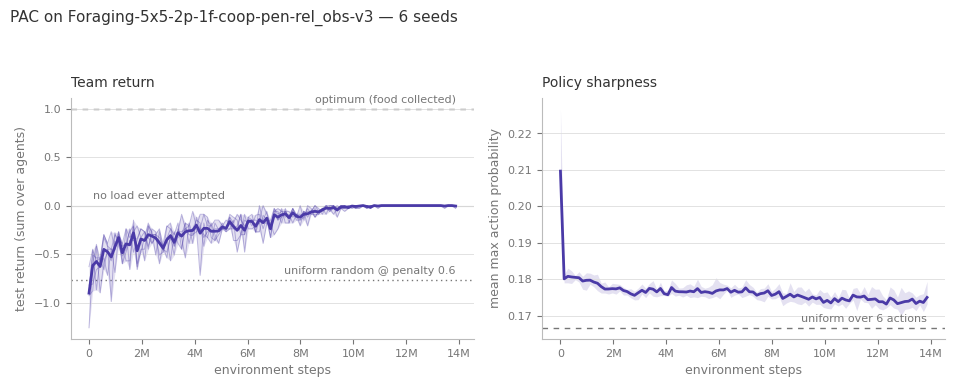

In [19]:
# Self-contained styling so this section runs without the matrix-game cells above.
PAC_COLOR = "#4a3aa7"   # same slot PAC has in every figure above
TEXT, MUTED = "#333333", "#767676"
N_ACTIONS = 6           # LBF: none, north, south, west, east, load


def curves(column, step_column="steps"):
    """(steps, per-seed curve matrix) for one metric, aligned on the shortest run."""
    n = min(len(s) for s in lbf_df[step_column])
    return (np.array(lbf_df[step_column].iloc[0][:n]),
            np.array([v[:n] for v in lbf_df[column]]))


REL_PENALTY = lbf_df["penalty"].iloc[0]  # inferred; see the loader cell

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))

steps, returns = curves("test_return")
ax = axes[0]
ax.axhline(LBF_OPTIMUM, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
ax.axhline(LBF_RANDOM[REL_PENALTY], color=MUTED, lw=1, ls=(0, (1, 2.5)), zorder=1)
ax.axhline(0.0, color="#bbbbbb", lw=0.8, zorder=1)
ax.fill_between(steps, returns.min(0), returns.max(0), color=PAC_COLOR, alpha=0.15, lw=0)
for curve in returns:  # 6 seeds: show them individually, the band alone hides how tight they are
    ax.plot(steps, curve, color=PAC_COLOR, lw=0.7, alpha=0.35)
ax.plot(steps, returns.mean(0), color=PAC_COLOR, lw=2, label="PAC")
ax.set_ylabel("test return (sum over agents)", fontsize=9, color=MUTED)
ax.set_title("Team return", loc="left", fontsize=10, color=TEXT, pad=8)
ax.annotate("optimum (food collected)", (steps[-1], LBF_OPTIMUM), xytext=(0, 4),
            textcoords="offset points", ha="right", fontsize=8, color=MUTED)
ax.annotate(f"uniform random @ penalty {REL_PENALTY}", (steps[-1], LBF_RANDOM[REL_PENALTY]), xytext=(0, 4),
            textcoords="offset points", ha="right", fontsize=8, color=MUTED)
ax.annotate("no load ever attempted", (steps[0], 0.0), xytext=(3, 5),
            textcoords="offset points", ha="left", fontsize=8, color=MUTED)

pi_steps, pi_curves = curves("pi_max", "pi_max_steps")
ax = axes[1]
ax.axhline(1 / N_ACTIONS, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
ax.fill_between(pi_steps, pi_curves.min(0), pi_curves.max(0), color=PAC_COLOR, alpha=0.15, lw=0)
ax.plot(pi_steps, pi_curves.mean(0), color=PAC_COLOR, lw=2)
ax.set_ylabel("mean max action probability", fontsize=9, color=MUTED)
ax.set_title("Policy sharpness", loc="left", fontsize=10, color=TEXT, pad=8)
ax.annotate(f"uniform over {N_ACTIONS} actions", (pi_steps[-1], 1 / N_ACTIONS), xytext=(0, 4),
            textcoords="offset points", ha="right", fontsize=8, color=MUTED)

for ax in axes:
    ax.set_xlabel("environment steps", fontsize=9, color=MUTED)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:g}M" if x else "0"))
    ax.grid(axis="y", color="#dddddd", lw=0.6)
    ax.tick_params(colors=MUTED, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#bbbbbb")
fig.suptitle(f"PAC on {LBF_ENV.split(':')[1]} — {len(lbf_df)} seeds",
             x=0.01, ha="left", fontsize=11, color=TEXT)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [20]:
# Per-seed endpoint. `final ep length` is the tell: episodes truncate at the
# 25-step limit in every seed, so the food is never collected -- the runs settle
# on "never attempt a load" rather than on the cooperative optimum.
lbf_summary = lbf_df.set_index("seed")[
    ["penalty", "final_return", "best_return", "final_ep_length", "duration_s"]
].rename(columns={
    "penalty": "penalty (inferred)",
    "final_return": "final return",
    "best_return": "best return",
    "final_ep_length": "final ep length",
    "duration_s": "hours/run",
})
lbf_summary["hours/run"] = lbf_summary["hours/run"] / 3600
lbf_summary.loc["mean"] = lbf_summary.mean()
lbf_summary.round(3)

,penalty (inferred),final return,best return,final ep length,hours/run
seed,,,,,
0,0.6,0.000,0.0,25.0,2.338
1,0.6,0.000,0.0,25.0,2.329
2,0.6,-0.030,0.0,25.0,2.347
3,0.6,0.000,0.0,25.0,2.333
4,0.6,0.000,0.0,25.0,0.664
5,0.6,0.000,0.0,25.0,0.661
mean,0.6,-0.005,0.0,25.0,1.778


### Stock absolute observations — but also a weaker penalty

The same task without `-rel_obs`, so positions arrive as **absolute** grid coordinates (at full sight the base env's `_transform_to_neighborhood` cancels out, `min(sight, center) == center`) and both agents read the same numbers up to player ordering.

**These runs also had a different penalty, so this is not a controlled comparison.** `penalty` is never written to the sacred config, and the registration in `lb-foraging/lbforaging/__init__.py` was changed from 0.6 to 0.1 partway through this project. Reconstructing it from the opening evaluation points (`infer_penalty` above) puts the six `-rel_obs` runs at **0.6** and all three of these at **0.1** — these curves start at ≈−0.15, those at ≈−0.9. Two variables moved at once.

**All three absolute-obs seeds reach the optimum**: best returns of 0.950, 0.985 and 0.990, with test episodes falling from the 25-step truncation to as low as 5.95, so the food is genuinely being collected rather than the return drifting up on partial credit. Seed 1 still holds it at the end (final 0.935); seeds 0 and 2 peak near 11.9M and then collapse back to ≈0. `final return` and `best return` therefore tell opposite stories and the table reports both.

No `-rel_obs` seed ever had an evaluation point average above zero.

**What this does and does not show.** The effect is large, but it cannot be pinned on the observation. Dropping the penalty from 0.6 to 0.1 moves the random-policy floor from −0.76 to −0.11 and makes the "never attempt a load" equilibrium far less attractive — the direction the reward-scale reading of the paper's figures predicted would matter. On this evidence the penalty is at least as plausible a cause as the observation wrapper, and the earlier reading of these panels (that the wrapper was the thing separating this setup from the paper) does not survive.

The decisive run is one variant at the other's penalty. That run exists — it is the `pac_pen_ns` section below, which holds the observation fixed at absolute and puts the penalty back to 0.6.

> A first attempt at the stock id (run 1) trained with `env_args.time_limit=1` and `t_max=50_000` — the one-step matrix-game defaults, from before `ENV_OVERRIDES` had a key for this id. The loader reports and drops it.

In [21]:
# name="pac_sarsa_ns": the pac_pen_ns runs live in this same directory
# (see the next section) and would otherwise be pooled in here.
lbf_abs_df = comparable_runs(LBF_ABS_ENV, name="pac_sarsa_ns")
print(f"{len(lbf_abs_df)} comparable run(s) loaded")
lbf_abs_df[["run", "seed", "name", "penalty", "final_return", "best_return",
            "best_return_step", "final_ep_length", "min_ep_length"]]

  dropped Foraging-5x5-2p-1f-coop-pen-v3 run 1: time_limit=1, t_max=50,000 (the one-step matrix-game defaults, not an LBF run)
3 comparable run(s) loaded


,run,seed,name,penalty,final_return,best_return,best_return_step,final_ep_length,min_ep_length
0,2,0,pac_sarsa_ns,0.1,-0.020,0.985,11908300,24.55,5.95
1,3,1,pac_sarsa_ns,0.1,0.935,0.950,13589796,10.15,7.90
2,4,2,pac_sarsa_ns,0.1,-0.125,0.990,11348554,25.00,6.95


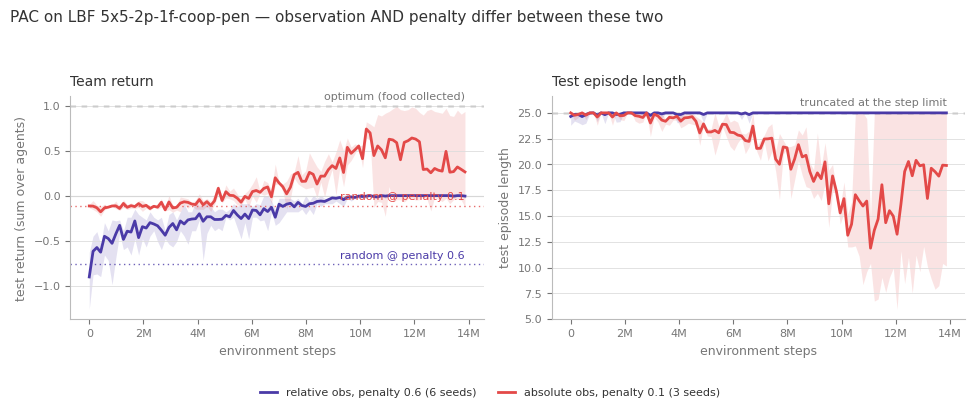

In [22]:
ABS_COLOR = "#e34948"  # absolute-observation runs, against PAC_COLOR for -rel_obs

SERIES = [(lbf_df, PAC_COLOR, "relative obs"), (lbf_abs_df, ABS_COLOR, "absolute obs")]


def aligned(df, column, step_column="steps"):
    """(steps, per-run curve matrix) for one metric, aligned on the shortest run."""
    n = min(len(s) for s in df[step_column])
    return (np.array(df[step_column].iloc[0][:n]),
            np.array([v[:n] for v in df[column]]))


fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
for ax, column, ylabel in [(axes[0], "test_return", "test return (sum over agents)"),
                           (axes[1], "ep_length", "test episode length")]:
    for df, color, name in SERIES:
        steps, curve_set = aligned(df, column)
        ax.fill_between(steps, curve_set.min(0), curve_set.max(0), color=color, alpha=0.15, lw=0)
        ax.plot(steps, curve_set.mean(0), color=color, lw=2,
                label=f"{name}, penalty {df['penalty'].iloc[0]} ({len(df)} seeds)")
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.set_xlabel("environment steps", fontsize=9, color=MUTED)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:g}M" if x else "0"))
    ax.grid(axis="y", color="#dddddd", lw=0.6)
    ax.tick_params(colors=MUTED, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#bbbbbb")

axes[0].axhline(LBF_OPTIMUM, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
axes[0].axhline(0.0, color="#bbbbbb", lw=0.8, zorder=1)
# One random-policy floor per variant, in that variant's colour: they were trained
# at different penalties, so a single shared reference line would be wrong for both.
for df, color, _ in SERIES:
    axes[0].axhline(LBF_RANDOM[df["penalty"].iloc[0]], color=color, lw=1,
                    ls=(0, (1, 2.5)), alpha=0.8, zorder=1)
axes[0].set_title("Team return", loc="left", fontsize=10, color=TEXT, pad=8)
axes[0].annotate("optimum (food collected)", (steps[-1], LBF_OPTIMUM), xytext=(0, 4),
                 textcoords="offset points", ha="right", fontsize=8, color=MUTED)
for df, color, _ in SERIES:
    floor = LBF_RANDOM[df["penalty"].iloc[0]]
    axes[0].annotate(f"random @ penalty {df['penalty'].iloc[0]}", (steps[-1], floor),
                     xytext=(0, 4), textcoords="offset points", ha="right",
                     fontsize=8, color=color)

# 25 = every test episode ran to the step limit, i.e. the food was not collected.
axes[1].axhline(25, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
axes[1].set_ylim(top=26.6)  # headroom so the label clears the curves sitting on 25
axes[1].set_title("Test episode length", loc="left", fontsize=10, color=TEXT, pad=8)
axes[1].annotate("truncated at the step limit", (steps[-1], 25), xytext=(0, 5),
                 textcoords="offset points", ha="right", fontsize=8, color=MUTED)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=2,
           frameon=False, fontsize=8, labelcolor=TEXT, handlelength=1.5)
fig.suptitle("PAC on LBF 5x5-2p-1f-coop-pen — observation AND penalty differ between these two",
             x=0.01, ha="left", fontsize=11, color=TEXT)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()

In [23]:
# `final return` and `best return` disagree sharply for the absolute-obs runs:
# two of the three reach the optimum and then lose it, so neither column
# summarises them alone. `min ep length` is the check on whether the food was
# ever actually collected. `penalty` is inferred, not recorded -- and it is not
# held constant across these two rows, so they are not a controlled comparison.
def variant_summary(df, label):
    best = df.loc[df["best_return"].idxmax()]
    return pd.Series({
        "optimum": LBF_OPTIMUM,
        "penalty": df["penalty"].iloc[0],
        "seeds": df["seed"].nunique(),
        "final return": df["final_return"].mean(),
        "best return": best["best_return"],
        "best return @": f"{best['best_return_step'] / 1e6:.1f}M",
        "seeds reaching >0.9": int((df["best_return"] > 0.9).sum()),
        "final ep length": df["final_ep_length"].mean(),
        "min ep length": df["min_ep_length"].min(),
    }, name=label)


lbf_compare = pd.DataFrame([
    variant_summary(lbf_df, "relative obs (-rel_obs)"),
    variant_summary(lbf_abs_df, "absolute obs (stock id)"),
])
lbf_compare.round(3)

,optimum,penalty,seeds,final return,best return,best return @,seeds reaching >0.9,final ep length,min ep length
relative obs (-rel_obs),1.0,0.6,6,-0.005,0.00,6.4M,0,25.0,23.80
absolute obs (stock id),1.0,0.1,3,0.263,0.99,11.3M,3,19.9,5.95


### `pac_pen_ns` — absolute observations at penalty 0.6

`ALG_OVERRIDES = {"pac_ns": [{"name": "pac_pen_ns"}]}` in `scripts/run_sweep.py` renames the sacred experiment, and that is how these two runs are told apart from the three above.

The override changes the recorded `name` but **not** the results directory: `src/main.py` builds the observer path from `config_dict['name']` *before* sacred applies the command-line override, so `pac_pen_ns` runs land in `results/sacred/pac_sarsa_ns/` interleaved with the rest and are separable only by the `name` field inside `config.json`. The loader reads it into a column and `comparable_runs(..., name=...)` filters on it — without that, these runs would silently merge into the panel above and average two different penalties together.

These are the missing cell of the 2×2: **absolute observations at penalty 0.6**, with everything else identical to the three runs above (`q_nstep=5`, `hidden_dim=128`, entropy 0.8 → 0.02, 25-step episodes, 14M steps).

**They fail exactly like the relative-observation runs.** Both seeds climb to the never-load plateau and stay there: best return 0.000, not one positive evaluation point, test episodes never dropping below 24.0 steps.

|  | penalty 0.6 | penalty 0.1 |
|---|---|---|
| **relative obs** | 6 seeds, best 0.000 | not run |
| **absolute obs** | 2 seeds, best 0.000 | 3 seeds, best 0.950 / 0.985 / 0.990 |

**This isolates the variable.** Holding the observation fixed at absolute and changing only the penalty flips the outcome from "never attempts a load in 14M steps" to "reaches the Pareto-optimal equilibrium in 3 of 3 seeds". The observation wrapper is not what separates this setup from the paper — the penalty scale is, which is the direction the random-policy floor (−0.76 against −0.11) pointed at all along.

One caveat on reading this as a reproduction: 0.1 is not the paper's setting either. Its figures imply an effective solo-failure cost near −0.3 — max-return line at 1.0 with the curves opening around −0.35 — whereas 0.1 opens at −0.11 and 0.6 at −0.76. So 0.1 overshoots in the easy direction, and the run that would actually match the paper is **penalty 0.3**, so far untested under either observation.

In [24]:
# name="pac_pen_ns": set via ALG_OVERRIDES in scripts/run_sweep.py. It lands in the
# same directory as the runs above (see the markdown), so filtering on it is what
# keeps the two penalties from being averaged together.
lbf_pen_df = comparable_runs(LBF_ABS_ENV, name="pac_pen_ns")
print(f"{len(lbf_pen_df)} run(s) loaded")
lbf_pen_df[["run", "seed", "name", "penalty", "final_return", "best_return",
            "final_ep_length", "min_ep_length"]]

2 run(s) loaded


,run,seed,name,penalty,final_return,best_return,final_ep_length,min_ep_length
0,5,1,pac_pen_ns,0.6,0.0,0.0,25.0,24.1
1,6,2,pac_pen_ns,0.6,0.0,0.0,25.0,24.0


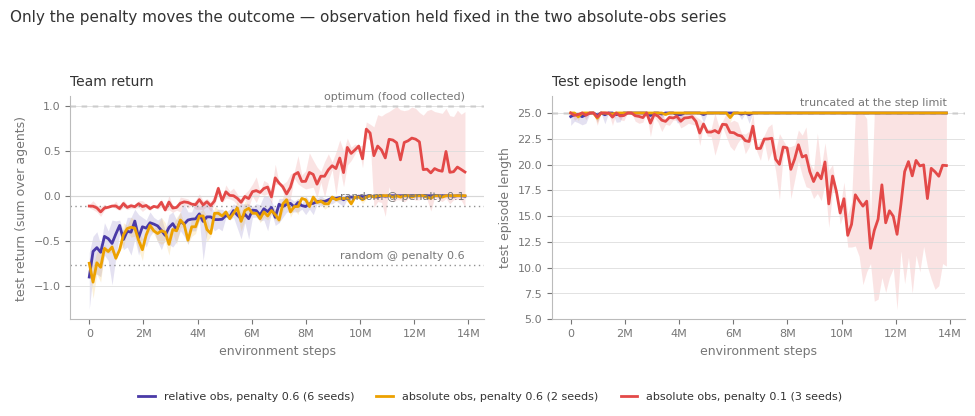

,optimum,penalty,seeds,final return,best return,best return @,seeds reaching >0.9,final ep length,min ep length
relative obs @ 0.6,1.0,0.6,6,-0.005,0.00,6.4M,0,25.0,23.80
absolute obs @ 0.6,1.0,0.6,2,0.000,0.00,9.3M,0,25.0,24.00
absolute obs @ 0.1,1.0,0.1,3,0.263,0.99,11.3M,3,19.9,5.95


In [ ]:
PEN_COLOR = "#eda100"  # absolute obs at penalty 0.6, the run that completes the 2x2

# Ordered so the two penalty-0.6 series sit next to each other in the legend:
# they are the ones that behave identically despite differing observations.
THREE = [(lbf_df, PAC_COLOR, "relative obs"),
         (lbf_pen_df, PEN_COLOR, "absolute obs"),
         (lbf_abs_df, ABS_COLOR, "absolute obs")]

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))
for ax, column, ylabel in [(axes[0], "test_return", "test return (sum over agents)"),
                           (axes[1], "ep_length", "test episode length")]:
    for df, color, name in THREE:
        steps, curve_set = aligned(df, column)
        ax.fill_between(steps, curve_set.min(0), curve_set.max(0), color=color, alpha=0.15, lw=0)
        ax.plot(steps, curve_set.mean(0), color=color, lw=2,
                label=f"{name}, penalty {df['penalty'].iloc[0]} ({len(df)} seeds)")
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.set_xlabel("environment steps", fontsize=9, color=MUTED)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:g}M" if x else "0"))
    ax.grid(axis="y", color="#dddddd", lw=0.6)
    ax.tick_params(colors=MUTED, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#bbbbbb")

axes[0].axhline(LBF_OPTIMUM, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
axes[0].axhline(0.0, color="#bbbbbb", lw=0.8, zorder=1)
# for penalty in sorted({df["penalty"].iloc[0] for df, _, _ in THREE}):
#     axes[0].axhline(LBF_RANDOM[penalty], color=MUTED, lw=1, ls=(0, (1, 2.5)), alpha=0.8, zorder=1)
#     axes[0].annotate(f"random @ penalty {penalty}", (steps[-1], LBF_RANDOM[penalty]),
#                      xytext=(0, 4), textcoords="offset points", ha="right",
#                      fontsize=8, color=MUTED)
axes[0].set_title("Team return", loc="left", fontsize=10, color=TEXT, pad=8)
axes[0].annotate("optimum (food collected)", (steps[-1], LBF_OPTIMUM), xytext=(0, 4),
                 textcoords="offset points", ha="right", fontsize=8, color=MUTED)

axes[1].axhline(25, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
axes[1].set_ylim(top=26.6)
axes[1].set_title("Test episode length", loc="left", fontsize=10, color=TEXT, pad=8)
axes[1].annotate("truncated at the step limit", (steps[-1], 25), xytext=(0, 5),
                 textcoords="offset points", ha="right", fontsize=8, color=MUTED)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3,
           frameon=False, fontsize=8, labelcolor=TEXT, handlelength=1.5)
fig.suptitle("Only the penalty moves the outcome — observation held fixed in the two absolute-obs series",
             x=0.01, ha="left", fontsize=11, color=TEXT)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()

lbf_three = pd.DataFrame([
    variant_summary(lbf_df, "relative obs @ 0.6"),
    variant_summary(lbf_pen_df, "absolute obs @ 0.6"),
    variant_summary(lbf_abs_df, "absolute obs @ 0.1"),
])
lbf_three.round(3)